In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
import os
os.listdir(path)

['list_landmarks_align_celeba.csv',
 'img_align_celeba',
 'list_eval_partition.csv',
 'list_attr_celeba.csv',
 'list_bbox_celeba.csv']

In [ ]:
image_dir = os.path.join(path, "img_align_celeba")

print(image_dir)
print(os.path.exists(image_dir))

/kaggle/input/celeba-dataset/img_align_celeba
True


In [ ]:
landmarks=os.path.join('list_landmarks_align_celeba.csv')

In [ ]:
print(landmarks)

list_landmarks_align_celeba.csv


In [ ]:
import pandas as pd

In [ ]:
import pandas as pd
from pathlib import Path

In [ ]:
data_dir = Path(path)


In [ ]:
attr_df = pd.read_csv(data_dir / "list_attr_celeba.csv")
partition_df = pd.read_csv(data_dir / "list_eval_partition.csv")
bbox_df = pd.read_csv(data_dir / "list_bbox_celeba.csv")
landmarks_df = pd.read_csv(data_dir / "list_landmarks_align_celeba.csv")

In [ ]:
print(attr_df.shape)
print(partition_df.shape)
print(bbox_df.shape)
print(landmarks_df.shape)

(202599, 41)
(202599, 2)
(202599, 5)
(202599, 11)


In [ ]:
df = attr_df.merge(
    partition_df,
    on="image_id"
)


In [ ]:
image_dir = os.path.join(image_dir, "img_align_celeba")


In [ ]:
print(os.listdir(image_dir)[:5])

['083648.jpg', '168202.jpg', '125778.jpg', '059339.jpg', '032501.jpg']


In [ ]:
df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(image_dir, x)
)

In [ ]:
df.sample(10)

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,partition,image_path
13755,013756.jpg,-1,1,1,-1,-1,-1,-1,1,-1,...,-1,1,1,-1,1,-1,-1,-1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
86745,086746.jpg,-1,-1,1,-1,-1,1,-1,-1,-1,...,-1,-1,-1,-1,1,1,-1,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
198030,198031.jpg,-1,-1,1,-1,-1,-1,-1,-1,1,...,-1,1,1,-1,1,-1,-1,1,2,/kaggle/input/celeba-dataset/img_align_celeba/...
24715,024716.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
58538,058539.jpg,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,1,1,-1,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
73248,073249.jpg,-1,-1,1,-1,-1,-1,-1,-1,1,...,-1,-1,-1,-1,-1,-1,-1,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
66167,066168.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,1,-1,-1,-1,-1,-1,-1,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
54620,054621.jpg,1,-1,1,1,-1,-1,-1,1,-1,...,-1,-1,-1,-1,-1,-1,-1,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
107750,107751.jpg,-1,-1,-1,1,-1,-1,-1,-1,-1,...,1,-1,-1,-1,-1,-1,-1,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
86579,086580.jpg,-1,-1,-1,-1,-1,-1,-1,-1,1,...,1,-1,-1,-1,-1,-1,-1,-1,0,/kaggle/input/celeba-dataset/img_align_celeba/...


In [ ]:
attribute_cols = attr_df.columns[1:]

df[attribute_cols] = df[attribute_cols].replace(-1, 0)

In [ ]:
df.sample(10)

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,partition,image_path
136527,136528.jpg,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,1,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
140483,140484.jpg,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
31931,031932.jpg,0,0,1,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
58271,058272.jpg,0,1,1,0,0,0,1,0,0,...,1,0,0,0,1,0,0,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
189858,189859.jpg,1,1,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,1,2,/kaggle/input/celeba-dataset/img_align_celeba/...
109471,109472.jpg,0,1,1,0,0,1,0,0,0,...,1,0,0,0,1,0,0,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
28423,028424.jpg,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
183819,183820.jpg,0,1,1,0,0,0,0,0,0,...,1,0,0,0,1,1,0,1,2,/kaggle/input/celeba-dataset/img_align_celeba/...
150285,150286.jpg,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...
160977,160978.jpg,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,1,0,/kaggle/input/celeba-dataset/img_align_celeba/...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202599 entries, 0 to 202598
Data columns (total 43 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   image_id             202599 non-null  object
 1   5_o_Clock_Shadow     202599 non-null  int64 
 2   Arched_Eyebrows      202599 non-null  int64 
 3   Attractive           202599 non-null  int64 
 4   Bags_Under_Eyes      202599 non-null  int64 
 5   Bald                 202599 non-null  int64 
 6   Bangs                202599 non-null  int64 
 7   Big_Lips             202599 non-null  int64 
 8   Big_Nose             202599 non-null  int64 
 9   Black_Hair           202599 non-null  int64 
 10  Blond_Hair           202599 non-null  int64 
 11  Blurry               202599 non-null  int64 
 12  Brown_Hair           202599 non-null  int64 
 13  Bushy_Eyebrows       202599 non-null  int64 
 14  Chubby               202599 non-null  int64 
 15  Double_Chin          202599 non-nu

In [ ]:
df=df.drop('image_id',axis=1)

In [ ]:
train_df=df[:30000]
val_df=df[162771:168000]
test_df=df[182638:188000]

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)
test_datagen=ImageDataGenerator(
    rescale=1./255
)



In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col=attribute_cols.tolist(),
    target_size=(128, 128),
    batch_size=128,
    class_mode="raw",
    shuffle=True
)
val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col=attribute_cols.tolist(),
    target_size=(128, 128),
    batch_size=128,
    class_mode="raw",
    shuffle=False
)
test_genrator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col=attribute_cols.tolist(),
    target_size=(128, 128),
    batch_size=128,
    class_mode="raw",
    shuffle=False
)



Found 30000 validated image filenames.
Found 5229 validated image filenames.
Found 5362 validated image filenames.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze MobileNetV2
base_model.trainable = False

model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(40, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,597,224 (9.91 MB)

 Trainable params: 338,728 (1.29 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy')]
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 207s 881ms/step - binary_accuracy: 0.8106 - loss: 0.4096 - val_binary_accuracy: 0.8644 - val_loss: 0.3067
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 194s 827ms/step - binary_accuracy: 0.8629 - loss: 0.3096 - val_binary_accuracy: 0.8678 - val_loss: 0.2957
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 202s 857ms/step - binary_accuracy: 0.8665 - loss: 0.3006 - val_binary_accuracy: 0.8685 - val_loss: 0.2944
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 189s 805ms/step - binary_accuracy: 0.8683 - loss: 0.2964 - val_binary_accuracy: 0.8703 - val_loss: 0.2919
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 200s 852ms/step - binary_accuracy: 0.8693 - loss: 0.2934 - val_binary_accuracy: 0.8712 - val_loss: 0.2890
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 190s 807ms/step - binary_accuracy: 0.8699 - loss: 0.2915 - val_binary_accuracy: 0.8725 - val_loss: 0.2872
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 191s 811ms/step - binary_accuracy: 0.8708 - loss: 0.2896 - val_binary_accuracy: 0.87

In [ ]:
model.save('face_model.h5')

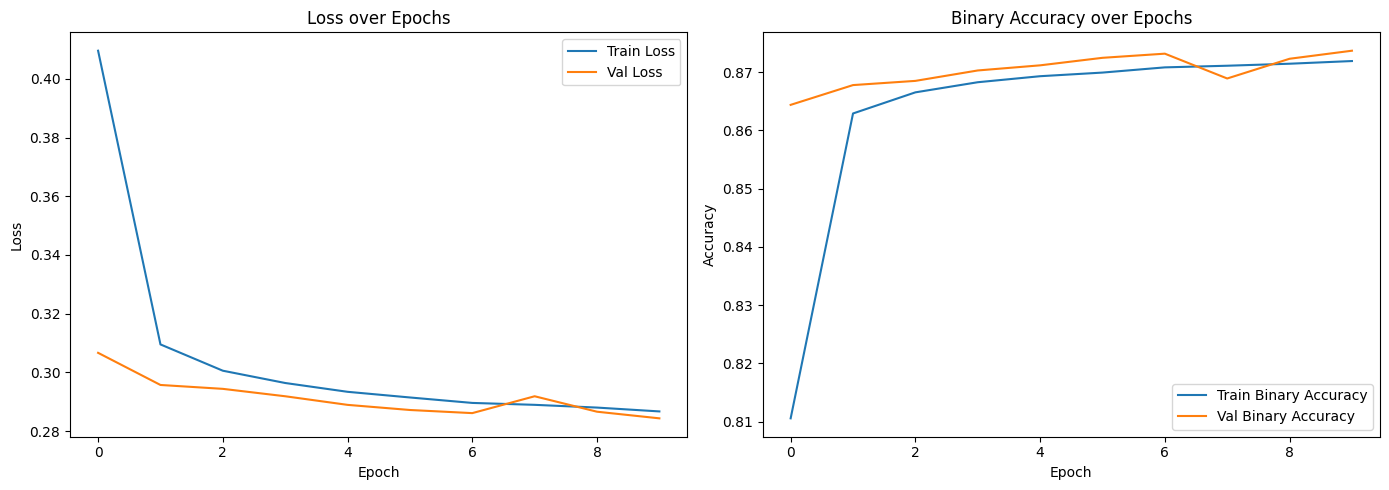

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['binary_accuracy'], label='Train Binary Accuracy')
axes[1].plot(history.history['val_binary_accuracy'], label='Val Binary Accuracy')
axes[1].set_title('Binary Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Predict probabilities (confidence scores) on test set
y_pred_probs = model.predict(test_genrator)   # shape: (num_samples, 40)
y_true = test_df[attribute_cols].values        # ground truth, shape: (num_samples, 40)

# Convert probabilities to binary predictions using 0.5 threshold
y_pred_binary = (y_pred_probs >= 0.5).astype(int)

print("Sample confidence scores for first image:")
for i, attr in enumerate(attribute_cols):
    print(f"{attr}: {y_pred_probs[0][i]:.3f}  (predicted: {y_pred_binary[0][i]}, actual: {y_true[0][i]})")

42/42 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step
Sample confidence scores for first image:
5_o_Clock_Shadow: 0.039  (predicted: 0, actual: 0)
Arched_Eyebrows: 0.343  (predicted: 0, actual: 0)
Attractive: 0.284  (predicted: 0, actual: 0)
Bags_Under_Eyes: 0.354  (predicted: 0, actual: 0)
Bald: 0.002  (predicted: 0, actual: 0)
Bangs: 0.032  (predicted: 0, actual: 0)
Big_Lips: 0.387  (predicted: 0, actual: 0)
Big_Nose: 0.286  (predicted: 0, actual: 1)
Black_Hair: 0.111  (predicted: 0, actual: 1)
Blond_Hair: 0.044  (predicted: 0, actual: 0)
Blurry: 0.028  (predicted: 0, actual: 0)
Brown_Hair: 0.269  (predicted: 0, actual: 0)
Bushy_Eyebrows: 0.116  (predicted: 0, actual: 1)
Chubby: 0.018  (predicted: 0, actual: 0)
Double_Chin: 0.006  (predicted: 0, actual: 0)
Eyeglasses: 0.002  (predicted: 0, actual: 0)
Goatee: 0.026  (predicted: 0, actual: 0)
Gray_Hair: 0.007  (predicted: 0, actual: 0)
Heavy_Makeup: 0.242  (predicted: 0, actual: 0)
High_Cheekbones: 0.243  (predicted: 0, actual: 1)
Male: 0.104  (predi

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred_binary,
    target_names=attribute_cols.tolist(),
    zero_division=0
)
print(report)

                     precision    recall  f1-score   support

   5_o_Clock_Shadow       0.53      0.34      0.41       528
    Arched_Eyebrows       0.60      0.48      0.53      1542
         Attractive       0.73      0.87      0.80      2667
    Bags_Under_Eyes       0.49      0.37      0.42      1055
               Bald       0.81      0.31      0.45       123
              Bangs       0.77      0.71      0.74       840
           Big_Lips       0.53      0.20      0.29      1793
           Big_Nose       0.50      0.55      0.53      1138
         Black_Hair       0.79      0.49      0.61      1530
         Blond_Hair       0.81      0.69      0.75       704
             Blurry       0.72      0.11      0.20       274
         Brown_Hair       0.56      0.37      0.45       956
     Bushy_Eyebrows       0.51      0.32      0.40       718
             Chubby       0.56      0.23      0.33       311
        Double_Chin       0.50      0.22      0.31       259
         Eyeglasses    

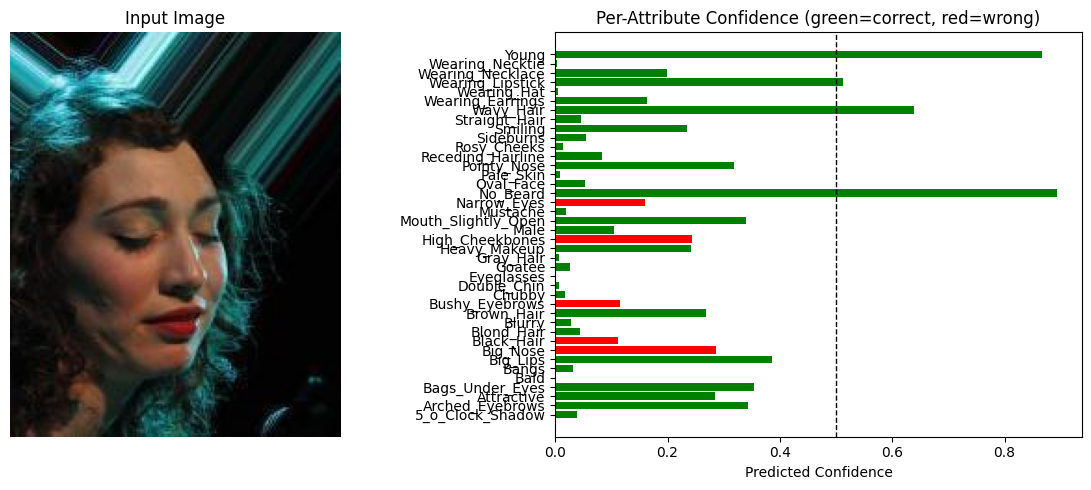

In [ ]:
import matplotlib.pyplot as plt

def show_prediction(index):
    img_path = test_df.iloc[index]["image_path"]
    img = plt.imread(img_path)

    probs = y_pred_probs[index]
    true_labels = y_true[index]

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(img)
    ax[0].axis('off')
    ax[0].set_title("Input Image")

    colors = ['green' if (p >= 0.5) == bool(t) else 'red' for p, t in zip(probs, true_labels)]
    ax[1].barh(attribute_cols, probs, color=colors)
    ax[1].axvline(0.5, color='black', linestyle='--', linewidth=1)
    ax[1].set_xlabel("Predicted Confidence")
    ax[1].set_title("Per-Attribute Confidence (green=correct, red=wrong)")
    plt.tight_layout()
    plt.show()

show_prediction(0)   # change index to view different test images

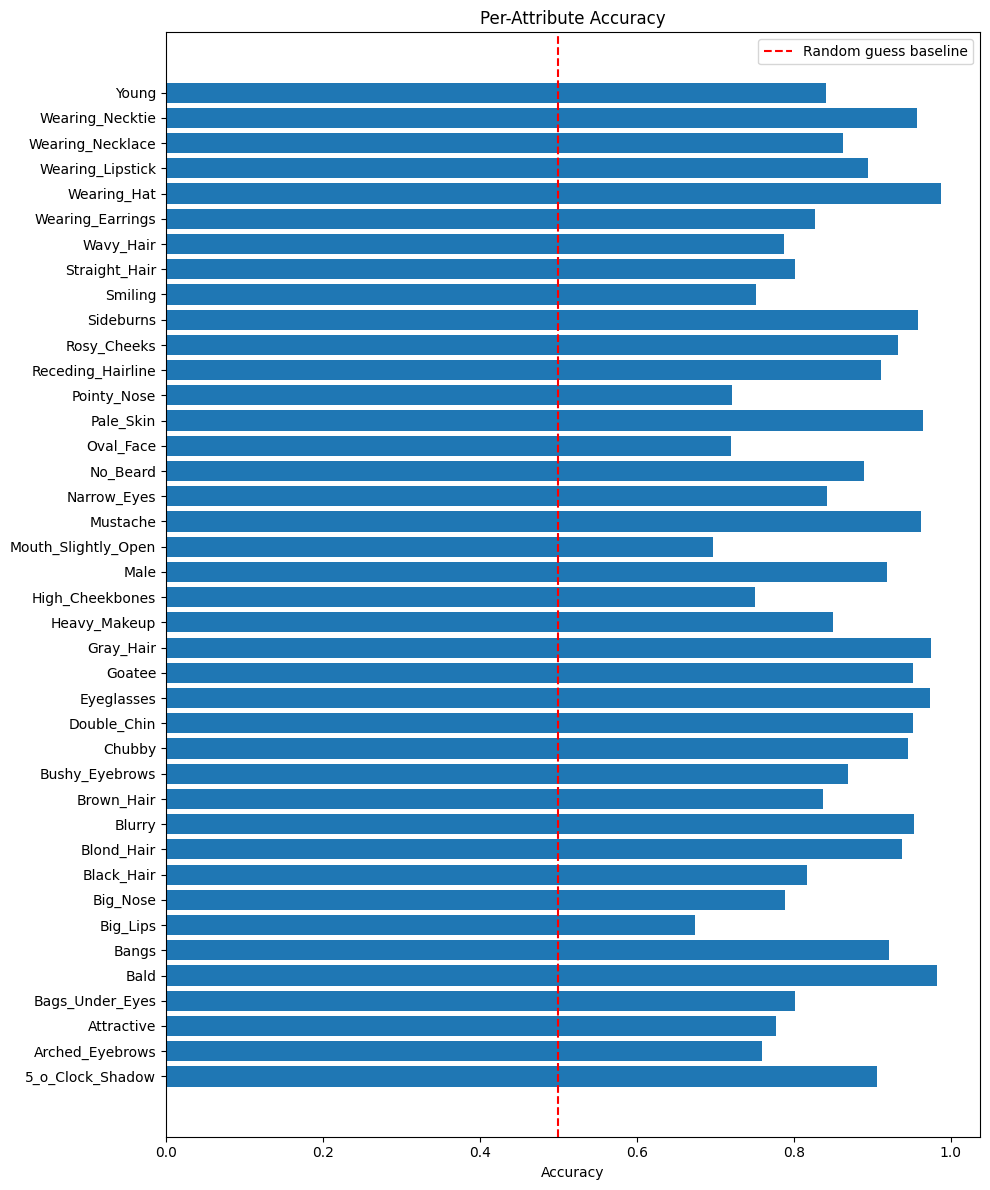

In [ ]:
per_attr_accuracy = (y_pred_binary == y_true).mean(axis=0)

plt.figure(figsize=(10, 12))
plt.barh(attribute_cols, per_attr_accuracy)
plt.xlabel("Accuracy")
plt.title("Per-Attribute Accuracy")
plt.axvline(0.5, color='red', linestyle='--', label='Random guess baseline')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import json

# Confirm these are your real attribute names first
print(attribute_cols)

Index(['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes',
       'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair',
       'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin',
       'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',
       'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
       'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline',
       'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair',
       'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick',
       'Wearing_Necklace', 'Wearing_Necktie', 'Young'],
      dtype='object')


In [ ]:
deployment_config = {
    "attribute_cols": list(attribute_cols),
    "thresholds": [0.5] * len(attribute_cols)   # or your tuned thresholds
}
with open("deployment_config.json", "w") as f:
    json.dump(deployment_config, f, indent=2)
